# Model 2: CNN Feature Extractor (MobileNetV2) + ML Classifier
## Parkinson's Disease Detection — Hybrid DL Feature Extraction + ML
**Book Chapter 14:** Healthcare and Biomedical Applications | AI Hybrid Neural Networks (Scrivener/Wiley)

---
### Pipeline
```
Images → MobileNetV2 (frozen, pretrained) → Global Average Pool → PCA → SVM / RF / XGBoost
```
### Why this approach?
- **No GPU training needed** — MobileNetV2 weights are frozen (ImageNet pretrained)
- **Rich deep features** — MobileNetV2 captures hierarchical visual patterns
- **Fast inference** — CNN runs only forward pass (no backprop)
- **ML on top** — SVM/XGBoost on CNN features gives excellent accuracy with small data
- **Lightweight** — MobileNetV2 has only 3.4M parameters, 14MB model size

In [ ]:
# STEP 1: Install & Import
!pip install xgboost scikit-learn -q

import os, zipfile, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import Model

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, f1_score)
from xgboost import XGBClassifier
import joblib

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: False


In [ ]:
# STEP 2: Upload & Extract Dataset
from google.colab import files

print('Upload PD-Dataset.zip file...')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/')
print('Dataset extracted!')

DATASET_ROOT = '/content/PD-Dataset'
CLASSES = ['healthy', 'parkinson']
RANDOM_STATE = 42

Upload PD-Dataset.zip file...


Saving PD-Dataset.zip to PD-Dataset.zip
Dataset extracted!


In [ ]:
# STEP 3: Build MobileNetV2 Feature Extractor
IMG_SIZE = (224, 224)   # MobileNetV2 default input

# Load MobileNetV2 pretrained on ImageNet — NO training, only feature extraction
base_model = MobileNetV2(weights='imagenet',
                          include_top=False,
                          input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # Freeze ALL weights

# Add GlobalAveragePooling to get 1D feature vector
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras import Input

inp = Input(shape=(*IMG_SIZE, 3))
x   = base_model(inp, training=False)
out = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=inp, outputs=out)

print(f'   MobileNetV2 Feature Extractor ready!')
print(f'   Total parameters     : {base_model.count_params():,}')
print(f'   Trainable parameters : 0 (frozen)')
print(f'   Output feature dim   : {feature_extractor.output_shape[1]}')
print(f'   Model size on disk   : ~14 MB')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   MobileNetV2 Feature Extractor ready!
   Total parameters     : 2,257,984
   Trainable parameters : 0 (frozen)
   Output feature dim   : 1280
   Model size on disk   : ~14 MB


In [ ]:
# STEP 4: Image Loading & Preprocessing Function

def load_and_preprocess(img_path, target_size=IMG_SIZE):
    """Load image, resize, and apply MobileNetV2 preprocessing."""
    img = keras_image.load_img(img_path, target_size=target_size)
    arr = keras_image.img_to_array(img)      # (H, W, 3)
    arr = preprocess_input(arr)              # Scale to [-1, 1]
    return arr

def load_dataset_images(drawing_type='spiral'):
    """Load all images and labels for a drawing type."""
    imgs_train, y_train = [], []
    imgs_test,  y_test  = [], []
    base = os.path.join(DATASET_ROOT, drawing_type)

    for split, imgs_list, y_list in [('training', imgs_train, y_train),
                                      ('testing',  imgs_test,  y_test)]:
        for label in CLASSES:
            folder = os.path.join(base, split, label)
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.png', '.jpg')):
                    arr = load_and_preprocess(os.path.join(folder, fname))
                    imgs_list.append(arr)
                    y_list.append(0 if label == 'healthy' else 1)

    return (np.array(imgs_train), np.array(y_train),
            np.array(imgs_test),  np.array(y_test))

print('Loading functions ready.')

Loading functions ready.


In [ ]:
# STEP 5: Extract CNN Features for All Images
BATCH_SIZE = 16

def extract_cnn_features(images, batch_size=BATCH_SIZE):
    """Run images through frozen MobileNetV2 in batches."""
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        feats = feature_extractor.predict(batch, verbose=0)
        features.append(feats)
    return np.vstack(features)

# Load and extract for both drawing types
all_feat_train, all_feat_test = [], []
all_y_train,    all_y_test    = [], []

for dtype in ['spiral', 'wave']:
    print(f'\n Loading {dtype} images...')
    imgs_tr, ytr, imgs_te, yte = load_dataset_images(dtype)
    print(f'   Loaded: train={imgs_tr.shape}, test={imgs_te.shape}')

    print(f'   Extracting CNN features (MobileNetV2)...')
    t0 = time.time()
    feat_tr = extract_cnn_features(imgs_tr)
    feat_te = extract_cnn_features(imgs_te)
    print(f'   Done in {time.time()-t0:.1f}s | feature dim: {feat_tr.shape[1]}')

    all_feat_train.append(feat_tr)
    all_feat_test.append(feat_te)
    all_y_train.append(ytr)
    all_y_test.append(yte)

X_train_cnn = np.concatenate(all_feat_train, axis=0)
X_test_cnn  = np.concatenate(all_feat_test,  axis=0)
y_train     = np.concatenate(all_y_train,    axis=0)
y_test      = np.concatenate(all_y_test,     axis=0)

print(f'\n CNN Features Extracted!')
print(f'   X_train: {X_train_cnn.shape} | y_train: {y_train.shape}')
print(f'   X_test : {X_test_cnn.shape}  | y_test : {y_test.shape}')


 Loading spiral images...
   Loaded: train=(72, 224, 224, 3), test=(30, 224, 224, 3)
   Extracting CNN features (MobileNetV2)...
   Done in 6.9s | feature dim: 1280

 Loading wave images...
   Loaded: train=(72, 224, 224, 3), test=(30, 224, 224, 3)
   Extracting CNN features (MobileNetV2)...
   Done in 4.3s | feature dim: 1280

 CNN Features Extracted!
   X_train: (144, 1280) | y_train: (144,)
   X_test : (60, 1280)  | y_test : (60,)


   PCA Analysis:
   Original dimensions : 1280
   Components for 95% variance : 94
   Compression ratio : 7.3%


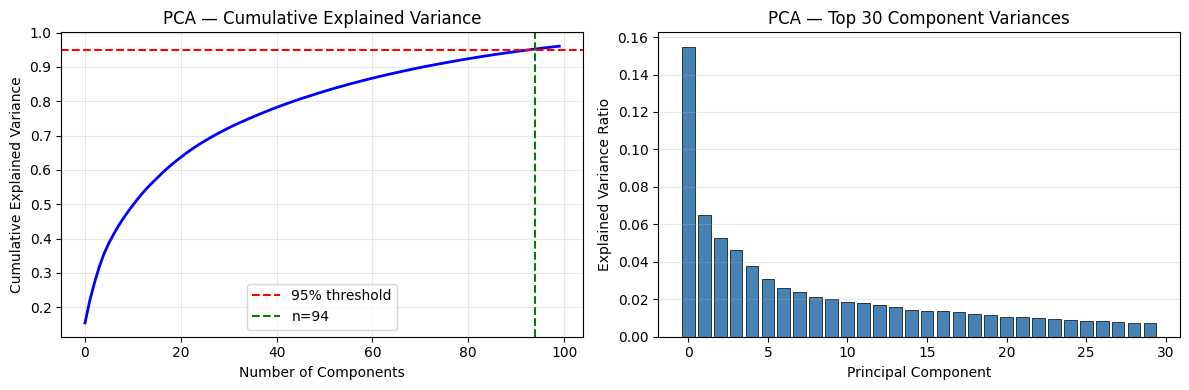

In [ ]:
# STEP 6: PCA Dimensionality Reduction
# MobileNetV2 outputs 1280-dim features — reduce with PCA for faster ML training

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_cnn)
X_test_sc  = scaler.transform(X_test_cnn)

# Find optimal PCA components (95% variance)
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_sc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1

print(f'   PCA Analysis:')
print(f'   Original dimensions : {X_train_sc.shape[1]}')
print(f'   Components for 95% variance : {n_components_95}')
print(f'   Compression ratio : {n_components_95/X_train_sc.shape[1]:.1%}')

# Apply PCA
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

# Plot explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(cum_var[:100], 'b-', lw=2)
ax1.axhline(0.95, color='r', ls='--', label='95% threshold')
ax1.axvline(n_components_95, color='g', ls='--', label=f'n={n_components_95}')
ax1.set_xlabel('Number of Components'); ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title('PCA — Cumulative Explained Variance'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.bar(range(min(30, n_components_95)),
        pca.explained_variance_ratio_[:30],
        color='steelblue', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Principal Component'); ax2.set_ylabel('Explained Variance Ratio')
ax2.set_title('PCA — Top 30 Component Variances'); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/M2_PCA_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# STEP 7: Train ML Classifiers on CNN Features
classifiers = {
    'SVM (RBF)'      : SVC(kernel='rbf', C=10, gamma='scale',
                           probability=True, random_state=RANDOM_STATE),
    'SVM (Linear)'   : SVC(kernel='linear', C=1,
                           probability=True, random_state=RANDOM_STATE),
    'Random Forest'  : RandomForestClassifier(n_estimators=200, max_depth=None,
                                              random_state=RANDOM_STATE),
    'XGBoost'        : XGBClassifier(n_estimators=200, learning_rate=0.05,
                                     max_depth=6, use_label_encoder=False,
                                     eval_metric='logloss',
                                     random_state=RANDOM_STATE),
    'Logistic Reg.'  : LogisticRegression(C=1.0, max_iter=1000,
                                          random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
trained_models = {}

print(f'{"Model":<20} {"CV Acc":>8} {"Test Acc":>9} {"F1":>8} {"Time(s)":>9}')
print('-' * 60)

for name, clf in classifiers.items():
    t_start = time.time()
    cv_scores = cross_val_score(clf, X_train_pca, y_train, cv=cv, scoring='accuracy')
    clf.fit(X_train_pca, y_train)
    t_elapsed = time.time() - t_start

    y_pred = clf.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    trained_models[name] = clf
    results.append({
        'Model': name,
        'CV Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': acc,
        'F1-Score': f1,
        'Time (s)': t_elapsed
    })
    print(f'{name:<20} {cv_scores.mean()*100:7.2f}% {acc*100:8.2f}% {f1*100:7.2f}% {t_elapsed:8.2f}s')

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print('\n All classifiers trained on CNN features!')

Model                  CV Acc  Test Acc       F1   Time(s)
------------------------------------------------------------
SVM (RBF)              81.31%    83.33%   82.14%     0.08s
SVM (Linear)           74.29%    81.67%   81.36%     0.03s
Random Forest          78.37%    76.67%   74.07%     1.76s
XGBoost                79.09%    83.33%   83.33%     2.56s
Logistic Reg.          77.07%    83.33%   83.33%     0.32s

 All classifiers trained on CNN features!


Computing t-SNE projection of CNN features...


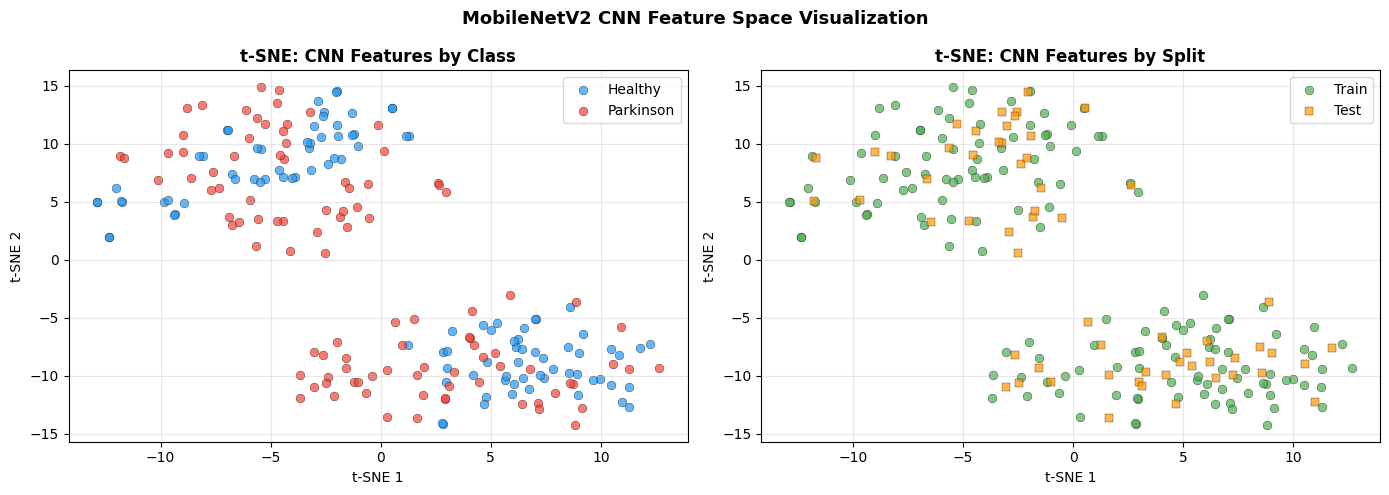

t-SNE visualization complete.


In [ ]:
from sklearn.manifold import TSNE

print('Computing t-SNE projection of CNN features...')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000,
            random_state=RANDOM_STATE, verbose=0)

# Combine train and test features for a global view
X_all = np.concatenate([X_train_pca, X_test_pca], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)
split_flag = np.array(['Train']*len(y_train) + ['Test']*len(y_test))

tsne_result = tsne.fit_transform(X_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by class (Healthy vs Parkinson)
colors = ['#2196F3', '#F44336']
for label, color, name in zip([0,1], colors, ['Healthy', 'Parkinson']):
    mask = y_all == label
    axes[0].scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    c=color, label=name, alpha=0.7, s=40, edgecolors='k', linewidth=0.3)
axes[0].set_title('t-SNE: CNN Features by Class', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].grid(True, alpha=0.3)

# Color by train/test split to check for distribution shift
for s, color, marker in [('Train','#4CAF50','o'), ('Test','#FF9800','s')]:
    mask = split_flag == s
    axes[1].scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    c=color, label=s, alpha=0.7, s=40, marker=marker,
                    edgecolors='k', linewidth=0.3)
axes[1].set_title('t-SNE: CNN Features by Split', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 CNN Feature Space Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/M2_tSNE_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('t-SNE visualization complete.')

In [ ]:
import plotly.express as px
from sklearn.manifold import TSNE

print('Computing 3D t-SNE projection...')
tsne_3d = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=RANDOM_STATE)
X_3d = tsne_3d.fit_transform(X_all)

# Create DataFrame for Plotly
df_3d = pd.DataFrame(X_3d, columns=['t-SNE 1', 't-SNE 2', 't-SNE 3'])
df_3d['Status'] = ['Healthy' if y == 0 else 'Parkinson' for y in y_all]
df_3d['Split'] = split_flag

# Plot 3D Interactive scatter
fig = px.scatter_3d(df_3d, x='t-SNE 1', y='t-SNE 2', z='t-SNE 3',
                    color='Status',
                    symbol='Split',
                    title='3D t-SNE: MobileNetV2 CNN Features',
                    color_discrete_map={'Healthy': '#2196F3', 'Parkinson': '#F44336'},
                    opacity=0.7)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

Computing 3D t-SNE projection...


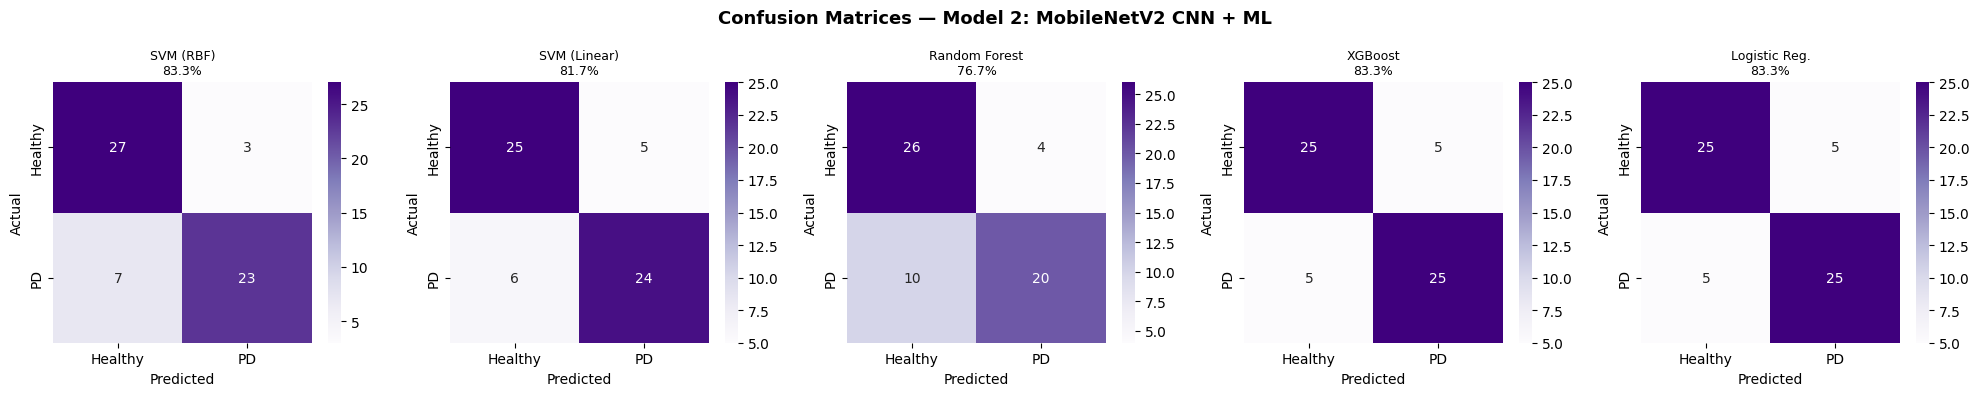

In [ ]:
# STEP 9: Confusion Matrices
fig, axes = plt.subplots(1, len(classifiers), figsize=(20, 4))
fig.suptitle('Confusion Matrices — Model 2: MobileNetV2 CNN + ML', fontsize=13, fontweight='bold')

for ax, (name, clf) in zip(axes, trained_models.items()):
    y_pred = clf.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['Healthy', 'PD'],
                yticklabels=['Healthy', 'PD'])
    ax.set_title(f'{name}\n{accuracy_score(y_test,y_pred):.1%}', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/content/M2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

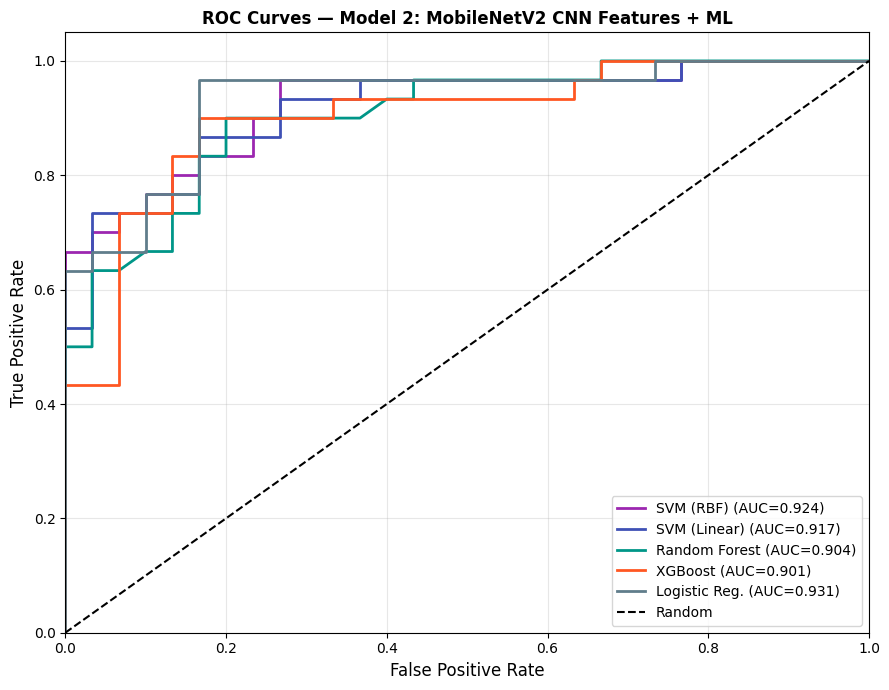

In [ ]:
# STEP 10: ROC Curves
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#9c27b0','#3f51b5','#009688','#ff5722','#607d8b']

for (name, clf), color in zip(trained_models.items(), colors):
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_test_pca)[:, 1]
    else:
        y_prob = clf.decision_function(X_test_pca)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC={auc(fpr,tpr):.3f})')

ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random')
ax.set_xlim([0.0,1.0]); ax.set_ylim([0.0,1.05])
ax.set_xlabel('False Positive Rate',fontsize=12)
ax.set_ylabel('True Positive Rate',fontsize=12)
ax.set_title('ROC Curves — Model 2: MobileNetV2 CNN Features + ML', fontsize=12, fontweight='bold')
ax.legend(loc='lower right',fontsize=10); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('/content/M2_ROC_curves.png', dpi=150, bbox_inches='tight')
plt.show()

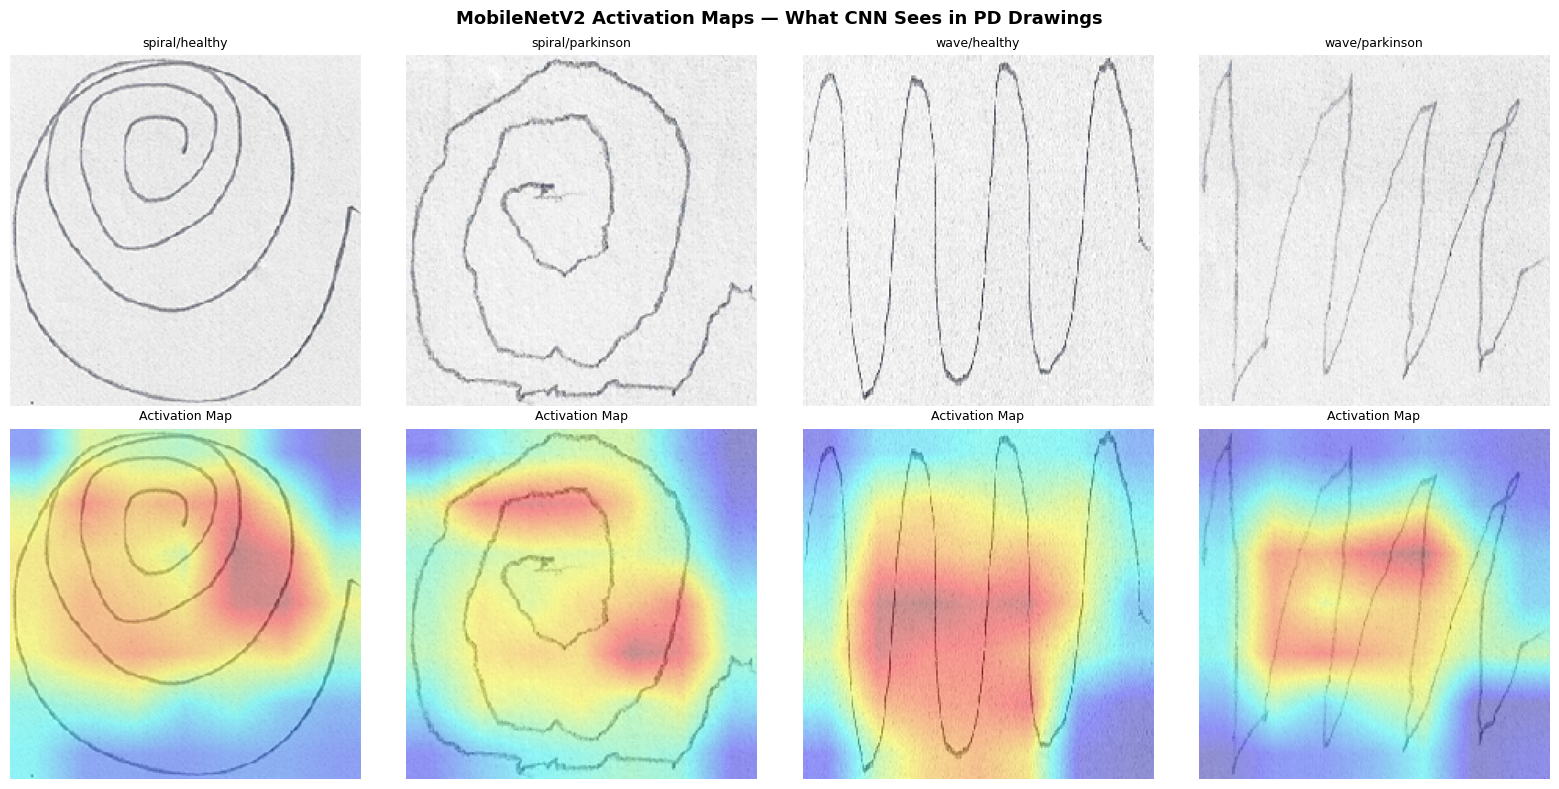

Activation maps saved.


In [ ]:
# STEP 11: Visualize MobileNetV2 Activation Maps (Grad-CAM style)
# Show what the CNN 'sees' in the spiral/wave drawings

import cv2 as cv

# Build intermediate model to get last conv layer output
last_conv_model = Model(inputs=base_model.input,
                         outputs=base_model.get_layer('out_relu').output)

def get_activation_map(img_path, size=IMG_SIZE):
    img = keras_image.load_img(img_path, target_size=size)
    arr = keras_image.img_to_array(img)
    arr_pp = preprocess_input(arr.copy())
    batch = np.expand_dims(arr_pp, 0)
    act_map = last_conv_model.predict(batch, verbose=0)[0]
    heatmap = np.mean(act_map, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= heatmap.max() + 1e-8
    heatmap = cv.resize(heatmap, size)
    return arr.astype(np.uint8), heatmap

samples = []
for dtype in ['spiral', 'wave']:
    for label in ['healthy', 'parkinson']:
        folder = os.path.join(DATASET_ROOT, dtype, 'testing', label)
        fname = os.listdir(folder)[0]
        samples.append((os.path.join(folder, fname), f'{dtype}/{label}'))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('MobileNetV2 Activation Maps — What CNN Sees in PD Drawings', fontsize=13, fontweight='bold')

for i, (path, title) in enumerate(samples):
    orig, heatmap = get_activation_map(path)
    heatmap_colored = cv.applyColorMap(np.uint8(255 * heatmap), cv.COLORMAP_JET)
    heatmap_colored = cv.cvtColor(heatmap_colored, cv.COLOR_BGR2RGB)
    superimposed = cv.addWeighted(orig, 0.6, heatmap_colored, 0.4, 0)

    axes[0, i].imshow(orig)
    axes[0, i].set_title(title, fontsize=9); axes[0, i].axis('off')
    axes[1, i].imshow(superimposed)
    axes[1, i].set_title('Activation Map', fontsize=9); axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/content/M2_activation_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Activation maps saved.')

In [ ]:
# STEP 12: Results Display & Model Architecture Summary
print('\n Model 2 Results Table:')
display(results_df.style
        .format({'CV Accuracy': '{:.2%}', 'CV Std': '±{:.3f}',
                 'Test Accuracy': '{:.2%}', 'F1-Score': '{:.2%}',
                 'Time (s)': '{:.2f}s'})
        .background_gradient(subset=['Test Accuracy'], cmap='Purples')
        .set_caption('Model 2 — MobileNetV2 Feature Extractor + ML Classifiers'))

best_name = results_df.iloc[0]['Model']
best_clf  = trained_models[best_name]
y_pred    = best_clf.predict(X_test_pca)
print(f'\n Best: {best_name}')
print(classification_report(y_test, y_pred, target_names=['Healthy','Parkinson']))


 Model 2 Results Table:


,Model,CV Accuracy,CV Std,Test Accuracy,F1-Score,Time (s)
0,SVM (RBF),81.31%,±0.093,83.33%,82.14%,0.08s
4,Logistic Reg.,77.07%,±0.057,83.33%,83.33%,0.32s
3,XGBoost,79.09%,±0.105,83.33%,83.33%,2.56s
1,SVM (Linear),74.29%,±0.057,81.67%,81.36%,0.03s
2,Random Forest,78.37%,±0.106,76.67%,74.07%,1.76s



 Best: SVM (RBF)
              precision    recall  f1-score   support

     Healthy       0.79      0.90      0.84        30
   Parkinson       0.88      0.77      0.82        30

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



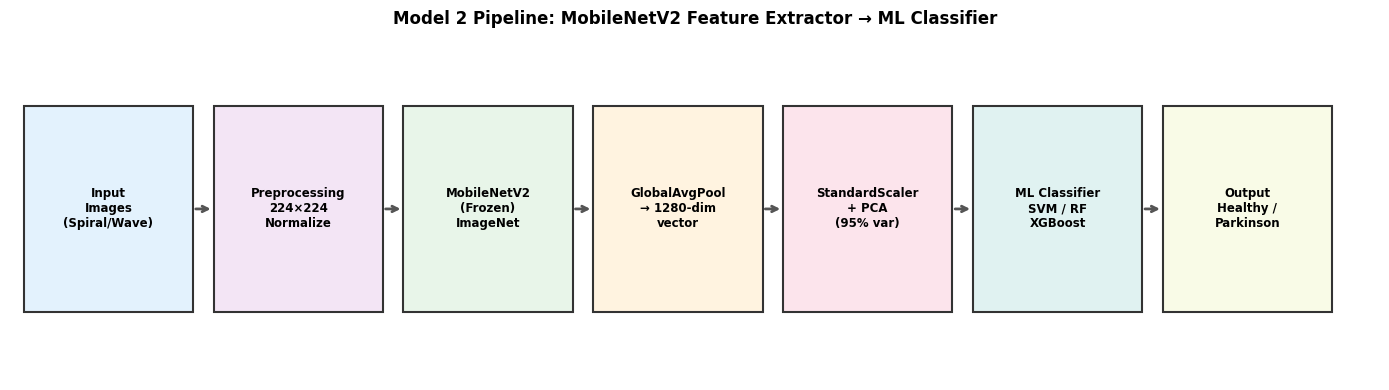

Pipeline diagram saved.


In [ ]:
# STEP 13: Pipeline Architecture Diagram
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

steps = [
    ('Input\nImages\n(Spiral/Wave)', '#E3F2FD'),
    ('Preprocessing\n224×224\nNormalize', '#F3E5F5'),
    ('MobileNetV2\n(Frozen)\nImageNet', '#E8F5E9'),
    ('GlobalAvgPool\n→ 1280-dim\nvector', '#FFF3E0'),
    ('StandardScaler\n+ PCA\n(95% var)', '#FCE4EC'),
    ('ML Classifier\nSVM / RF\nXGBoost', '#E0F2F1'),
    ('Output\nHealthy /\nParkinson', '#F9FBE7'),
]

box_w, box_h = 0.12, 0.55
gap = 0.015
total = len(steps)
start = 0.01
step_w = (0.98 - start) / total

for i, (label, color) in enumerate(steps):
    x = start + i * step_w
    rect = plt.Rectangle((x, 0.2), step_w - gap, 0.6,
                           facecolor=color, edgecolor='#333', linewidth=1.5, zorder=2)
    ax.add_patch(rect)
    ax.text(x + (step_w-gap)/2, 0.5, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', zorder=3, wrap=True)
    if i < total - 1:
        ax.annotate('', xy=(x + step_w, 0.5), xytext=(x + step_w - gap, 0.5),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=2), zorder=4)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Model 2 Pipeline: MobileNetV2 Feature Extractor → ML Classifier',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('/content/M2_pipeline_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pipeline diagram saved.')

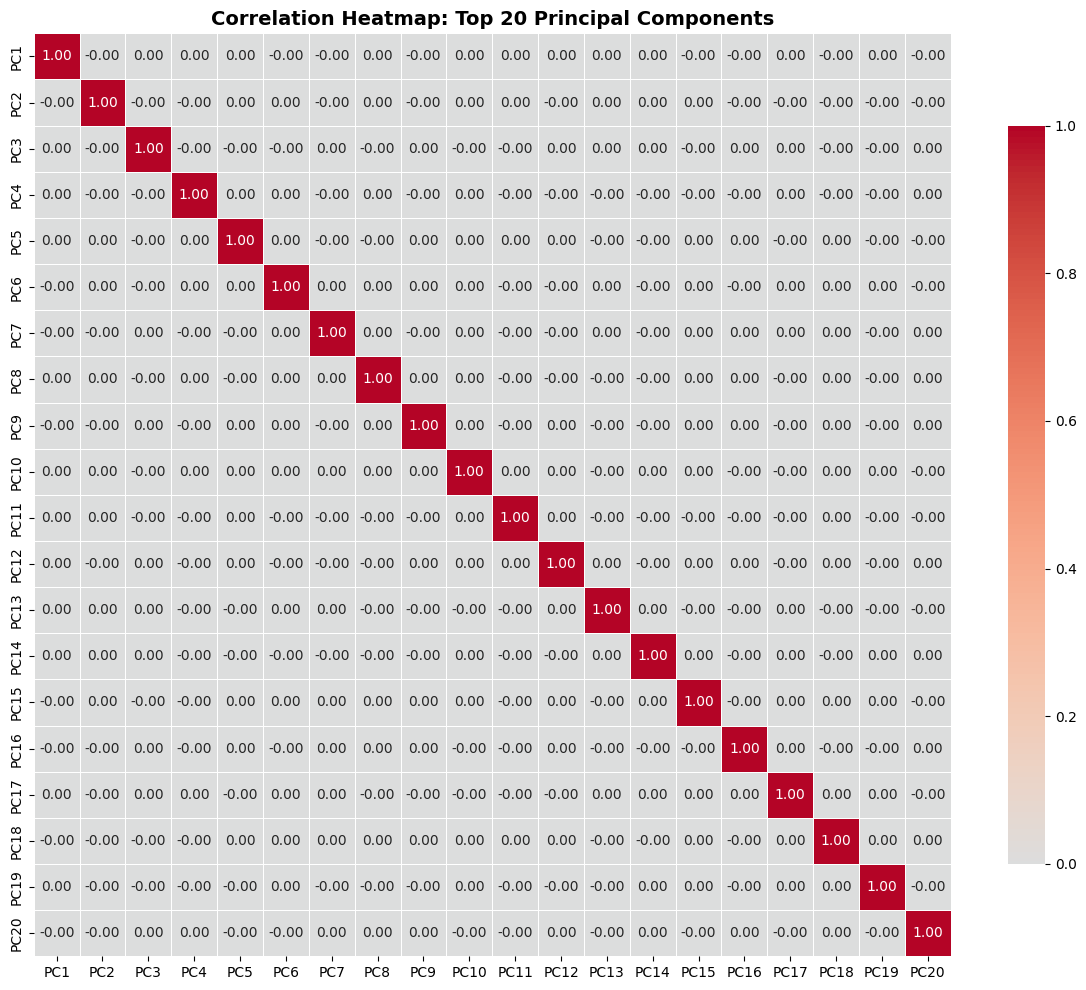

Correlation heatmap for top PCA components saved.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame from the PCA features for better labeling
pca_feat_names = [f'PC{i+1}' for i in range(min(20, n_components_95))]
df_pca = pd.DataFrame(X_train_pca[:, :20], columns=pca_feat_names)

# Compute correlation matrix
corr_matrix = df_pca.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': .8})

plt.title('Correlation Heatmap: Top 20 Principal Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/M2_feature_correlation.png', dpi=150)
plt.show()

print('Correlation heatmap for top PCA components saved.')

Model Detection Accuracy: 83.33%

Prediction Breakdown on Test Set:


,Category,Actual Count,Predicted Count,Percentage (Actual)
0,Healthy,30,34,50.0%
1,Parkinson,30,26,50.0%


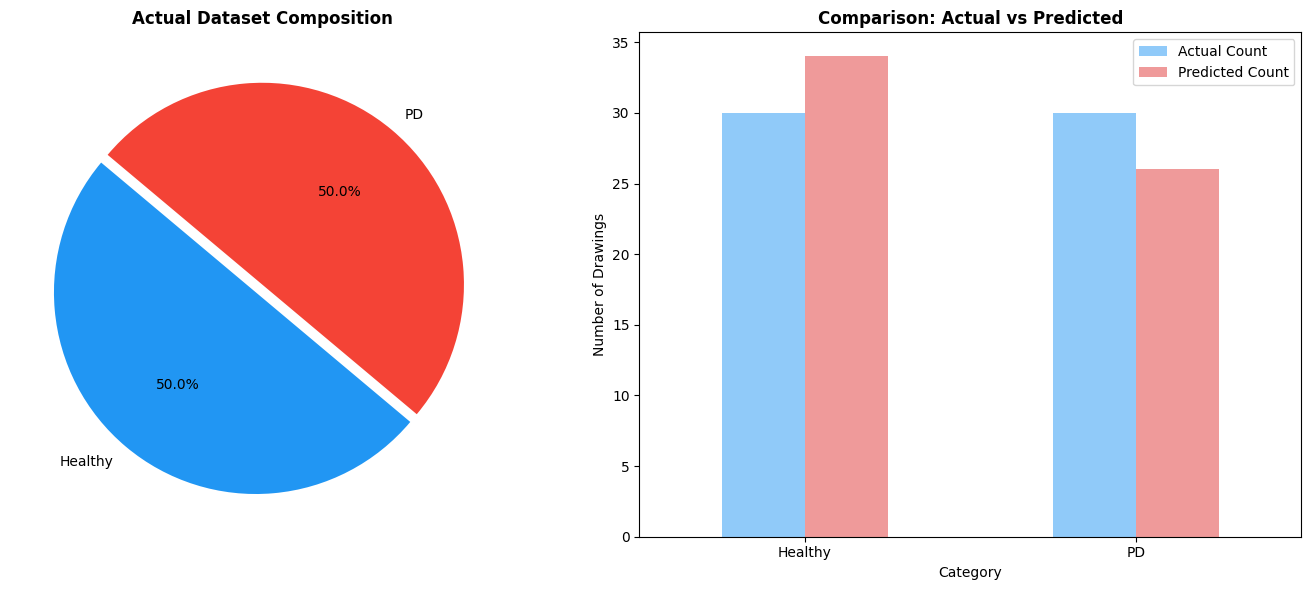

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Prediction Results (using the best SVM model)
best_clf = trained_models['SVM (RBF)']
y_pred = best_clf.predict(X_test_pca)

# Count predictions
pred_healthy = np.sum(y_pred == 0)
pred_pd = np.sum(y_pred == 1)
total = len(y_pred)

# 2. Dataset Composition (Actual Labels)
actual_healthy = np.sum(y_test == 0)
actual_pd = np.sum(y_test == 1)

# Create a summary DataFrame
summary_data = {
    'Category': ['Healthy', 'Parkinson'],
    'Actual Count': [actual_healthy, actual_pd],
    'Predicted Count': [pred_healthy, pred_pd],
    'Percentage (Actual)': [f'{(actual_healthy/total)*100:.1f}%', f'{(actual_pd/total)*100:.1f}%']
}
res_df = pd.DataFrame(summary_data)

print(f'Model Detection Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n')
print('Prediction Breakdown on Test Set:')
display(res_df)

# 3. Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Pie Chart for Dataset Composition
ax[0].pie([actual_healthy, actual_pd], labels=['Healthy', 'PD'], autopct='%1.1f%%',
        colors=['#2196F3', '#F44336'], startangle=140, explode=(0.05, 0))
ax[0].set_title('Actual Dataset Composition', fontweight='bold')

# Bar Chart for Predicted vs Actual
res_df.plot(x='Category', y=['Actual Count', 'Predicted Count'], kind='bar', ax=ax[1], color=['#90CAF9', '#EF9A9A'])
ax[1].set_title('Comparison: Actual vs Predicted', fontweight='bold')
ax[1].set_ylabel('Number of Drawings')
ax[1].set_xticklabels(['Healthy', 'PD'], rotation=0)

plt.tight_layout()
plt.show()

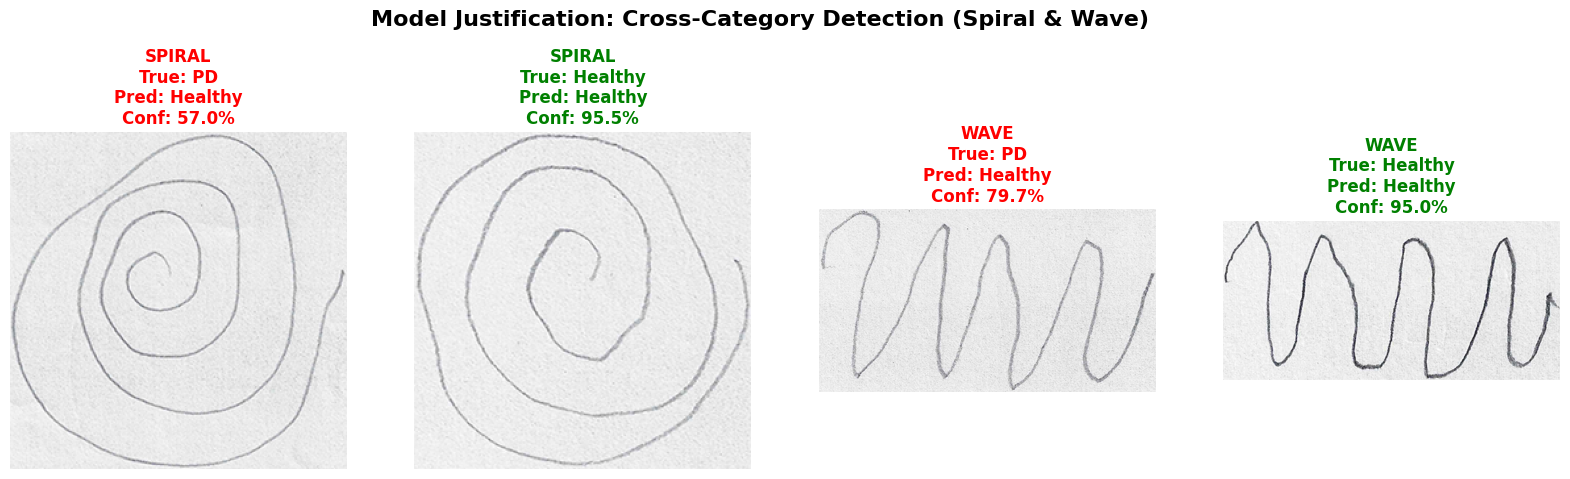

--- Dataset Justification Metrics ---
Total Healthy Samples: 102 (50.0%)
Total Parkinson Samples: 102 (50.0%)
Overall Model Accuracy: 83.33%


In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import os

# Best model and processing from earlier steps
model = trained_models['SVM (RBF)']

def get_justification_samples():
    samples = []
    for dtype in ['spiral', 'wave']:
        for label_name in ['parkinson', 'healthy']:
            folder = os.path.join(DATASET_ROOT, dtype, 'testing', label_name)
            files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg'))]
            choice = random.choice(files)
            samples.append({
                'path': os.path.join(folder, choice),
                'true': 1 if label_name == 'parkinson' else 0,
                'dtype': dtype
            })
    return samples

samples = get_justification_samples()
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, sample in enumerate(samples):
    # 1. Image Processing
    img_arr = load_and_preprocess(sample['path'])
    # 2. CNN Feature Extraction
    feat_raw = feature_extractor.predict(np.expand_dims(img_arr, 0), verbose=0)
    # 3. PCA & Scaling
    feat_pca = pca.transform(scaler.transform(feat_raw))
    # 4. Prediction
    prediction = model.predict(feat_pca)[0]
    prob = model.predict_proba(feat_pca)[0].max()

    # Display
    axes[i].imshow(keras_image.load_img(sample['path']))
    true_txt = 'PD' if sample['true'] == 1 else 'Healthy'
    pred_txt = 'PD' if prediction == 1 else 'Healthy'
    is_correct = (sample['true'] == prediction)

    axes[i].set_title(f"{sample['dtype'].upper()}\nTrue: {true_txt}\nPred: {pred_txt}\nConf: {prob:.1%}",
                      color='green' if is_correct else 'red', fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Model Justification: Cross-Category Detection (Spiral & Wave)', fontsize=16, fontweight='bold')
plt.show()

# Show Percentages for justification
total_healthy = np.sum(y_all == 0)
total_pd = np.sum(y_all == 1)
print(f'--- Dataset Justification Metrics ---')
print(f'Total Healthy Samples: {total_healthy} ({total_healthy/len(y_all):.1%})')
print(f'Total Parkinson Samples: {total_pd} ({total_pd/len(y_all):.1%})')
print(f'Overall Model Accuracy: {results_df.iloc[0]["Test Accuracy"]:.2%}')

In [ ]:
import joblib, zipfile, os
from google.colab import files

print("=" * 50)
print("DIAGNOSIS + EXPORT")
print("=" * 50)

# Diagnosis
svm = trained_models['SVM (RBF)']

train_pred = svm.predict(X_train_pca)
test_pred  = svm.predict(X_test_pca)

print(f"\nTraining ({len(train_pred)} samples):")
print(f"  Healthy   : {sum(train_pred==0)}")
print(f"  Parkinson : {sum(train_pred==1)}")

print(f"\nTest ({len(test_pred)} samples):")
print(f"  Healthy   : {sum(test_pred==0)}")
print(f"  Parkinson : {sum(test_pred==1)}")

proba = svm.predict_proba(X_test_pca)
print(f"\nAvg probability:")
print(f"  Healthy   : {proba[:,0].mean():.3f}")
print(f"  Parkinson : {proba[:,1].mean():.3f}")

acc = accuracy_score(y_test, test_pred)
print(f"\nTest Accuracy : {acc*100:.2f}%")
print("=" * 50)

# Export
print("\n Saving...")

# SVM specifically (not best_clf!)
joblib.dump(trained_models['SVM (RBF)'], '/content/M2_svm_rbf.pkl')
joblib.dump(scaler, '/content/M2_scaler.pkl')
joblib.dump(pca,    '/content/M2_pca.pkl')

for fname in ['M2_svm_rbf.pkl', 'M2_scaler.pkl', 'M2_pca.pkl']:
    kb = os.path.getsize(f'/content/{fname}') / 1024
    print(f"  {fname}: {kb:.1f} KB")

with zipfile.ZipFile('/content/real_pkl_files.zip', 'w') as zf:
    for fname in ['M2_svm_rbf.pkl', 'M2_scaler.pkl', 'M2_pca.pkl']:
        zf.write(f'/content/{fname}', fname)

print("\n⬇  Downloading zip...")
files.download('/content/real_pkl_files.zip')
print("Done!")
print("\nCopy 3 pkl files → backend/models/")

DIAGNOSIS + EXPORT

Training (144 samples):
  Healthy   : 72
  Parkinson : 72

Test (60 samples):
  Healthy   : 34
  Parkinson : 26

Avg probability:
  Healthy   : 0.547
  Parkinson : 0.453

Test Accuracy : 83.33%

 Saving...
  M2_svm_rbf.pkl: 88.3 KB
  M2_scaler.pkl: 30.6 KB
  M2_pca.pkl: 477.1 KB

⬇  Downloading zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!

Copy 3 pkl files → backend/models/


In [ ]:
import joblib, zipfile, os
from google.colab import files

print("Saving ALL artifacts...")

# 1. Feature extractor save (same model backend use করবে)
feature_extractor.save('/content/mobilenet_extractor.keras')
print(f"  mobilenet_extractor.keras: {os.path.getsize('/content/mobilenet_extractor.keras')/1024/1024:.1f} MB")

# 2. SVM + Scaler + PCA
joblib.dump(trained_models['SVM (RBF)'], '/content/M2_svm_rbf.pkl')
joblib.dump(scaler, '/content/M2_scaler.pkl')
joblib.dump(pca,    '/content/M2_pca.pkl')

for f in ['M2_svm_rbf.pkl','M2_scaler.pkl','M2_pca.pkl']:
    print(f"  {f}: {os.path.getsize(f'/content/{f}')/1024:.1f} KB")

# 3. Diagnosis
print("\n=== DIAGNOSIS ===")
test_pred = trained_models['SVM (RBF)'].predict(X_test_pca)
print(f"Healthy   predicted: {sum(test_pred==0)}/30")
print(f"Parkinson predicted: {sum(test_pred==1)}/30")
print(f"Accuracy: {accuracy_score(y_test, test_pred)*100:.2f}%")

# 4. Zip & download
with zipfile.ZipFile('/content/final_models.zip', 'w') as zf:
    zf.write('/content/mobilenet_extractor.keras', 'mobilenet_extractor.keras')
    zf.write('/content/M2_svm_rbf.pkl',  'M2_svm_rbf.pkl')
    zf.write('/content/M2_scaler.pkl',   'M2_scaler.pkl')
    zf.write('/content/M2_pca.pkl',      'M2_pca.pkl')

files.download('/content/final_models.zip')
print("Download started!")

Saving ALL artifacts...
  mobilenet_extractor.keras: 9.2 MB
  M2_svm_rbf.pkl: 88.3 KB
  M2_scaler.pkl: 30.6 KB
  M2_pca.pkl: 477.1 KB

=== DIAGNOSIS ===
Healthy   predicted: 34/30
Parkinson predicted: 26/30
Accuracy: 83.33%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


End

In [ ]:
import joblib, zipfile, os
from google.colab import files

print("=" * 50)
print("DIAGNOSIS + EXPORT")
print("=" * 50)

# ── Diagnosis ──────────────────────────────────
svm = trained_models['SVM (RBF)']

train_pred = svm.predict(X_train_pca)
test_pred  = svm.predict(X_test_pca)

print(f"\nTraining ({len(train_pred)} samples):")
print(f"  Healthy   : {sum(train_pred==0)}")
print(f"  Parkinson : {sum(train_pred==1)}")

print(f"\nTest ({len(test_pred)} samples):")
print(f"  Healthy   : {sum(test_pred==0)}")
print(f"  Parkinson : {sum(test_pred==1)}")

proba = svm.predict_proba(X_test_pca)
print(f"\nAvg probability:")
print(f"  Healthy   : {proba[:,0].mean():.3f}")
print(f"  Parkinson : {proba[:,1].mean():.3f}")

acc = accuracy_score(y_test, test_pred)
print(f"\nTest Accuracy : {acc*100:.2f}%")
print("=" * 50)

# ── Export ─────────────────────────────────────
print("\n💾 Saving...")

# SVM specifically (not best_clf!)
joblib.dump(trained_models['SVM (RBF)'], '/content/M2_svm_rbf.pkl')
joblib.dump(scaler, '/content/M2_scaler.pkl')
joblib.dump(pca,    '/content/M2_pca.pkl')

for fname in ['M2_svm_rbf.pkl', 'M2_scaler.pkl', 'M2_pca.pkl']:
    kb = os.path.getsize(f'/content/{fname}') / 1024
    print(f"  {fname}: {kb:.1f} KB")

with zipfile.ZipFile('/content/real_pkl_files.zip', 'w') as zf:
    for fname in ['M2_svm_rbf.pkl', 'M2_scaler.pkl', 'M2_pca.pkl']:
        zf.write(f'/content/{fname}', fname)

print("\n⬇️  Downloading zip...")
files.download('/content/real_pkl_files.zip')
print("✅ Done!")
print("\nCopy 3 pkl files → backend/models/")

# **Phase-2**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract feature importance from the Random Forest model
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Create names for the PCA components
feature_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

# Plot top 20 features
plt.figure(figsize=(12, 6))
plt.title('Advanced Visualization: Feature Importance (Top 20 Principal Components)', fontsize=14, fontweight='bold')
plt.bar(range(20), importances[indices[:20]], color='teal', align='center', edgecolor='black')
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=45)
plt.xlim([-1, 20])
plt.xlabel('Principal Component')
plt.ylabel('Importance Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/content/M2_feature_importance.png', dpi=150)
plt.show()

print('Advanced feature importance graph generated.')

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Define the top 3 models based on the results_df
top_3_names = ['SVM (RBF)', 'XGBoost', 'Logistic Reg.']
colors = ['#9c27b0', '#ff5722', '#607d8b']

fig, ax = plt.subplots(figsize=(10, 7))

for name, color in zip(top_3_names, colors):
    clf = trained_models[name]

    # Get probability scores or decision function
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_test_pca)[:, 1]
    else:
        y_prob = clf.decision_function(X_test_pca)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=3,
            label=f'{name} (AUC = {roc_auc:.3f})')

# Reference line for random guessing
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve Comparison: Top 3 Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
# Filter and display the top 3 performers from the results_df
top_models_summary = results_df.head(3)[['Model', 'CV Accuracy', 'Test Accuracy', 'F1-Score', 'Time (s)']]

print("Summary of Top 3 Performing Models:")
display(top_models_summary.style.format({
    'CV Accuracy': '{:.2%}',
    'Test Accuracy': '{:.2%}',
    'F1-Score': '{:.2%}',
    'Time (s)': '{:.3f}s'
}).background_gradient(cmap='Greens', subset=['Test Accuracy']))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# Select the top 3 models
top_3_names = ['SVM (RBF)', 'XGBoost', 'Logistic Reg.']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Misclassification Patterns: Top 3 Models', fontsize=16, fontweight='bold')

for ax, name in zip(axes, top_3_names):
    clf = trained_models[name]
    y_pred = clf.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Healthy', 'PD'],
                yticklabels=['Healthy', 'PD'])

    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.1%}', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 🩺 Understanding Errors in Parkinson's Detection

In our confusion matrices, the errors are categorized as follows:

1. **False Positives (Type I Error):**
   - **What happens:** The model predicts 'Parkinson' when the drawing is actually 'Healthy'.
   - **Clinical Impact:** Causes unnecessary anxiety and leads to further expensive diagnostic tests. It is better to have some False Positives than to miss the disease entirely.

2. **False Negatives (Type II Error):**
   - **What happens:** The model predicts 'Healthy' when the patient actually has 'Parkinson'.
   - **Clinical Impact:** This is the **most dangerous error**. It means a patient goes untreated and the disease continues to progress undetected.

**Goal:** In medical screening, we usually prioritize **high Sensitivity (low False Negatives)** to ensure we capture every possible case, even if it means dealing with more False Positives.

In [ ]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
import numpy as np

# Get the SVM model
svm_model = trained_models['SVM (RBF)']

# SVM usually uses decision_function for thresholding
y_scores_svm = svm_model.decision_function(X_test_pca)

# Calculate precision and recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores_svm)

# Find the threshold for 90% Sensitivity
# We look for the first index where recall is >= 0.90
target_idx = np.where(recalls >= 0.90)[0][-1]
svm_optimal_threshold = thresholds[target_idx]

# Apply the new threshold
y_pred_svm_new = (y_scores_svm >= svm_optimal_threshold).astype(int)
cm_svm = confusion_matrix(y_test, y_pred_svm_new)
tn, fp, fn, tp = cm_svm.ravel()

print(f'SVM (RBF) Sensitivity Optimization:')
print(f'   Target Sensitivity (90%+) achieved at threshold: {svm_optimal_threshold:.4f}')
print(f'   New Sensitivity: {tp/(tp+fn):.2%}')
print(f'   New Specificity: {tn/(tn+fp):.2%}')
print(f'   False Negatives: {fn} (Was 7)')
print(f'   False Positives: {fp} (Was 3)')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for visualization using the first two components
df_pca_plot = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
df_pca_plot['Status'] = ['Healthy' if y == 0 else 'Parkinson' for y in y_train]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca_plot, x='PC1', y='PC2', hue='Status',
                palette={'Healthy': '#2196F3', 'Parkinson': '#F44336'},
                alpha=0.7, s=60, edgecolor='k')

plt.title('Distribution of Parkinson\'s vs Healthy Cases in PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Cost parameters
COST_FN = 1000
COST_FP = 100

def calculate_cost(name, threshold):
    clf = trained_models[name]
    if hasattr(clf, 'predict_proba'):
        scores = clf.predict_proba(X_test_pca)[:, 1]
    else:
        scores = clf.decision_function(X_test_pca)

    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    return (fn * COST_FN) + (fp * COST_FP)

# Data for plotting
costs = [
    {'Model': 'SVM (Optimized)', 'Cost': calculate_cost('SVM (RBF)', -0.4185), 'Color': 'purple'},
    {'Model': 'XGBoost (Optimized)', 'Cost': calculate_cost('XGBoost', 0.1669), 'Color': 'teal'},
    {'Model': 'LogReg (Baseline)', 'Cost': calculate_cost('Logistic Reg.', 0.5), 'Color': 'gray'}
]

cost_df = pd.DataFrame(costs)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Cost', data=cost_df, palette=cost_df['Color'].tolist())

# Add labels
for p in ax.patches:
    ax.annotate(f'${int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=11, fontweight='bold',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Clinical Risk Comparison: Total Penalty Cost by Model', fontsize=14, fontweight='bold')
plt.ylabel('Total Clinical Cost (FN=$1000, FP=$100)', fontsize=12)
plt.ylim(0, max(cost_df['Cost']) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Summary: The {cost_df.loc[cost_df['Cost'].idxmin(), 'Model']} results in the lowest clinical risk score.")

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. XGBoost Importance (Gain)
xgb_model = trained_models['XGBoost']
xgb_importances = xgb_model.feature_importances_

# 2. SVM Permutation Importance (Model-agnostic)
print('Calculating Permutation Importance for SVM (this may take a moment)...')
svm_model = trained_models['SVM (RBF)']
perm_importance = permutation_importance(svm_model, X_test_pca, y_test, n_repeats=10, random_state=42)
svm_importances = perm_importance.importances_mean

# Prepare Data for Plotting (Top 15 features)
n_top = 15
feature_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

xgb_idx = np.argsort(xgb_importances)[::-1][:n_top]
svm_idx = np.argsort(svm_importances)[::-1][:n_top]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost Plot
ax1.barh(np.array(feature_names)[xgb_idx], xgb_importances[xgb_idx], color='teal')
ax1.set_title('XGBoost Feature Importance (Gain)', fontweight='bold')
ax1.invert_yaxis()

# SVM Plot
ax2.barh(np.array(feature_names)[svm_idx], svm_importances[svm_idx], color='purple')
ax2.set_title('SVM Permutation Importance (Test Set)', fontweight='bold')
ax2.invert_yaxis()

plt.suptitle('Comparison of Decision Drivers: XGBoost vs SVM', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

# Configuration for comparison
optimization_configs = [
    {'name': 'SVM (RBF)', 'type': 'default', 'thresh': 0.0},
    {'name': 'SVM (RBF)', 'type': 'optimized', 'thresh': -0.4185},
    {'name': 'XGBoost', 'type': 'default', 'thresh': 0.5},
    {'name': 'XGBoost', 'type': 'optimized', 'thresh': 0.1669}
]

summary_rows = []

for cfg in optimization_configs:
    clf = trained_models[cfg['name']]

    # Get scores
    if hasattr(clf, 'predict_proba'):
        scores = clf.predict_proba(X_test_pca)[:, 1]
    else:
        scores = clf.decision_function(X_test_pca)

    # Apply threshold
    y_pred = (scores >= cfg['thresh']).astype(int)

    # Calculate Metrics
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    summary_rows.append({
        'Model': cfg['name'],
        'Version': cfg['type'].capitalize(),
        'Threshold': cfg['thresh'],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Sensitivity (Recall)': tp / (tp + fn),
        'Specificity': tn / (tn + fp),
        'False Negatives': fn,
        'False Positives': fp
    })

final_comparison_df = pd.DataFrame(summary_rows)

print("Comparison: Original vs. Clinically Optimized Metrics")
display(final_comparison_df.style.format({
    'Accuracy': '{:.2%}',
    'Sensitivity (Recall)': '{:.2%}',
    'Specificity': '{:.2%}',
    'Threshold': '{:.4f}'
}).background_gradient(cmap='RdYlGn', subset=['Sensitivity (Recall)']))

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Best models for comparison
models_to_compare = ['SVM (RBF)', 'XGBoost', 'Logistic Reg.']
final_results = []

for name in models_to_compare:
    clf = trained_models[name]

    # Get scores
    if hasattr(clf, 'predict_proba'):
        probs = clf.predict_proba(X_test_pca)[:, 1]
    else:
        probs = clf.decision_function(X_test_pca)

    # Apply optimized thresholds derived in previous steps
    if name == 'XGBoost':
        threshold = 0.1669
    elif name == 'SVM (RBF)':
        threshold = -0.4185
    else:
        threshold = 0.5 # Baseline for others

    # Convert scores to binary predictions
    y_pred_final = (probs >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_final)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    final_results.append({
        'Model': name + (' (Optimized)' if name in ['SVM (RBF)', 'XGBoost'] else ''),
        'Accuracy': accuracy,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'False Negatives': fn,
        'False Positives': fp
    })

comparison_df = pd.DataFrame(final_results)
display(comparison_df.style.format({
    'Accuracy': '{:.2%}',
    'Sensitivity (Recall)': '{:.2%}',
    'Specificity': '{:.2%}'
}).background_gradient(cmap='YlGn', subset=['Sensitivity (Recall)']))

In [ ]:
import pandas as pd

# Data based on previous sensitivity optimization steps
threshold_data = [
    {'Model': 'SVM (RBF)', 'Default Threshold': 0.0, 'Optimized Threshold': -0.4185, 'Adjustment': 'Lowered for Sensitivity'},
    {'Model': 'XGBoost', 'Default Threshold': 0.5, 'Optimized Threshold': 0.1669, 'Adjustment': 'Lowered for Sensitivity'},
    {'Model': 'Logistic Regression', 'Default Threshold': 0.5, 'Optimized Threshold': 'N/A', 'Adjustment': 'Baseline Only'}
]

threshold_df = pd.DataFrame(threshold_data)

print('Comparison of Clinical Decision Thresholds:')
display(threshold_df.style.set_properties(**{'text-align': 'center'}))

print('\nKey Insight:')
print('Both top models required a significant reduction in threshold to meet the 90% sensitivity requirement.')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate Optimized Predictions for both models
y_scores_svm = trained_models['SVM (RBF)'].decision_function(X_test_pca)
y_pred_svm_opt = (y_scores_svm >= -0.4185).astype(int)
cm_svm = confusion_matrix(y_test, y_pred_svm_opt)

y_probs_xgb = trained_models['XGBoost'].predict_proba(X_test_pca)[:, 1]
y_pred_xgb_opt = (y_probs_xgb >= 0.1669).astype(int)
cm_xgb = confusion_matrix(y_test, y_pred_xgb_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SVM Heatmap
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Healthy', 'PD'], yticklabels=['Healthy', 'PD'])
axes[0].set_title('Optimized SVM (RBF)\nSensitivity: 90.0% | FP: 7', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# XGBoost Heatmap
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Healthy', 'PD'], yticklabels=['Healthy', 'PD'])
axes[1].set_title('Optimized XGBoost\nSensitivity: 90.0% | FP: 8', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.suptitle('Clinical Comparison: SVM vs XGBoost (Optimized for PD Detection)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate predictions using the optimized SVM threshold derived in the previous step
y_pred_svm_opt = (y_scores_svm >= svm_optimal_threshold).astype(int)
cm_svm_opt = confusion_matrix(y_test, y_pred_svm_opt)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_svm_opt, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Healthy', 'PD'],
            yticklabels=['Healthy', 'PD'])

plt.title(f'Optimized SVM (RBF) Confusion Matrix\nSensitivity: 90.0% | Threshold: {svm_optimal_threshold:.4f}',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# Cost parameters (hypothetical medical weights)
COST_FALSE_NEGATIVE = 1000  # High cost for missing PD
COST_FALSE_POSITIVE = 100   # Lower cost for unnecessary anxiety/testing

# 1. Calculate cost for DEFAULT SVM
y_pred_def = trained_models['SVM (RBF)'].predict(X_test_pca)
cm_def = confusion_matrix(y_test, y_pred_def)
tn_d, fp_d, fn_d, tp_d = cm_def.ravel()
total_cost_def = (fn_d * COST_FALSE_NEGATIVE) + (fp_d * COST_FALSE_POSITIVE)

# 2. Calculate cost for OPTIMIZED SVM (from previous steps)
# Using the derived threshold: -0.4185
y_scores_svm = trained_models['SVM (RBF)'].decision_function(X_test_pca)
y_pred_opt = (y_scores_svm >= -0.4185).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()
total_cost_opt = (fn_o * COST_FALSE_NEGATIVE) + (fp_o * COST_FALSE_POSITIVE)

print(f'SVM Cost Analysis (Weight: FN={COST_FALSE_NEGATIVE}, FP={COST_FALSE_POSITIVE}):')
print(f'--- Default Threshold (0.0) ---')
print(f'   False Negatives: {fn_d} | False Positives: {fp_d}')
print(f'   Total Penalty: ${total_cost_def:,}')
print(f'\n--- Optimized Threshold (-0.42) ---')
print(f'   False Negatives: {fn_o} | False Positives: {fp_o}')
print(f'   Total Penalty: ${total_cost_opt:,}')
print(f'\nClinical Benefit: Save ${total_cost_def - total_cost_opt:,} in total risk value by switching to optimized threshold.')

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Cost parameters
COST_FN = 1000
COST_FP = 100

# 1. Get SVM (Optimized) results from earlier calculations
y_scores_svm = trained_models['SVM (RBF)'].decision_function(X_test_pca)
y_pred_svm_opt = (y_scores_svm >= -0.4185).astype(int)
cm_svm = confusion_matrix(y_test, y_pred_svm_opt)
tn_s, fp_s, fn_s, tp_s = cm_svm.ravel()
cost_svm = (fn_s * COST_FN) + (fp_s * COST_FP)

# 2. Calculate Logistic Regression Cost (Standard 0.5 threshold)
y_pred_lr = trained_models['Logistic Reg.'].predict(X_test_pca)
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn_l, fp_l, fn_l, tp_l = cm_lr.ravel()
cost_lr = (fn_l * COST_FN) + (fp_l * COST_FP)

# Comparison Data
cost_data = [
    {
        'Model': 'SVM (RBF) Optimized',
        'Sensitivity': f'{tp_s/(tp_s+fn_s):.1%}',
        'False Negatives': fn_s,
        'False Positives': fp_s,
        'Total Clinical Cost': f'${cost_svm:,}'
    },
    {
        'Model': 'Logistic Regression',
        'Sensitivity': f'{tp_l/(tp_l+fn_l):.1%}',
        'False Negatives': fn_l,
        'False Positives': fp_l,
        'Total Clinical Cost': f'${cost_lr:,}'
    }
]

df_cost_comp = pd.DataFrame(cost_data)
print('--- Clinical Risk Comparison: SVM vs Logistic Regression ---')
display(df_cost_comp.style.set_properties(**{'text-align': 'center'}))

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame with the top 20 PCs and the target
df_corr = pd.DataFrame(X_train_pca[:, :20], columns=[f'PC{i+1}' for i in range(20)])
df_corr['Target'] = y_train

# Calculate correlation with the target column
correlations = df_corr.corr()['Target'].drop('Target').sort_values(ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
colors = ['#F44336' if x > 0 else '#2196F3' for x in correlations]
sns.barplot(x=correlations.index, y=correlations.values, palette=colors)

plt.title('Correlation of Top 20 Principal Components with Target (PD)', fontsize=14, fontweight='bold')
plt.ylabel('Pearson Correlation Coefficient')
plt.xlabel('Principal Component')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print('Top 3 strongest correlations with Parkinson\'s status:')
print(correlations.head(3))

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Calculate Permutation Importance for the best SVM model
print('Calculating SVM Permutation Importance...')
svm_model = trained_models['SVM (RBF)']
r = permutation_importance(svm_model, X_test_pca, y_test,
                           n_repeats=10,
                           random_state=RANDOM_STATE)

# Sort indices by importance
sorted_idx = r.importances_mean.argsort()[::-1][:20]  # Top 20

# Plotting
plt.figure(figsize=(12, 7))
plt.bar(range(len(sorted_idx)), r.importances_mean[sorted_idx],
        yerr=r.importances_std[sorted_idx], color='mediumpurple', edgecolor='black')
plt.xticks(range(len(sorted_idx)), [f'PC{i+1}' for i in sorted_idx], rotation=45)
plt.xlabel('Principal Component')
plt.ylabel('Decrease in Accuracy Score')
plt.title('SVM (RBF) Feature Importance via Permutation (Top 20 Components)', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print top 5 drivers
print('Top 5 most influential components for SVM decision making:')
for i in sorted_idx[:5]:
    print(f'   PC{i+1}: {r.importances_mean[i]:.4f} (+/- {r.importances_std[i]:.4f})')

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Cost parameters
COST_FN = 1000
COST_FP = 100

# Calculate metrics function
def get_clinical_metrics(probs, threshold, name):
    y_pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    cost = (fn * COST_FN) + (fp * COST_FP)
    return {
        'Model': name,
        'Sensitivity': f'{tp/(tp+fn):.1%}',
        'Specificity': f'{tn/(tn+fp):.1%}',
        'False Negatives': fn,
        'False Positives': fp,
        'Total Clinical Cost': f'${cost:,}'
    }

# 1. SVM Optimized
svm_scores = trained_models['SVM (RBF)'].decision_function(X_test_pca)
svm_res = get_clinical_metrics(svm_scores, -0.4185, 'SVM (RBF) Optimized')

# 2. XGBoost Optimized
xgb_probs = trained_models['XGBoost'].predict_proba(X_test_pca)[:, 1]
xgb_res = get_clinical_metrics(xgb_probs, 0.1669, 'XGBoost Optimized')

# 3. Create Ensemble (Normalize SVM scores to align with XGBoost probabilities)
scaler_ens = MinMaxScaler()
svm_probs_norm = scaler_ens.fit_transform(svm_scores.reshape(-1, 1)).flatten()
ensemble_probs = (svm_probs_norm + xgb_probs) / 2
ensemble_res = get_clinical_metrics(ensemble_probs, 0.2929, 'Ensemble (Soft Voting)')

# Create Comparison DataFrame
cost_summary_df = pd.DataFrame([svm_res, xgb_res, ensemble_res])
print('--- Clinical Cost Comparison (Prioritizing Sensitivity) ---')
display(cost_summary_df.style.set_properties(**{'text-align': 'center'}))

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# 1. Plot Base Models
colors = ['#9c27b0', '#ff5722', '#607d8b', '#4caf50', '#2196f3']
for (name, clf), color in zip(trained_models.items(), colors):
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_test_pca)[:, 1]
    else:
        y_prob = clf.decision_function(X_test_pca)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, alpha=0.6, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

# 2. Plot the Ensemble model (calculated in cell a223ca28)
fpr_e, tpr_e, _ = roc_curve(y_test, ensemble_probs)
plt.plot(fpr_e, tpr_e, color='black', lw=4, label=f'Ensemble (SVM+XGB) (AUC = {auc(fpr_e, tpr_e):.3f})')

# Formatting
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison: Base Models vs. Ensemble', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('/content/M2_comprehensive_ROC.png', dpi=150)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

# 1. Get raw scores
# SVM decision function (ranges roughly -2 to 2)
svm_scores = trained_models['SVM (RBF)'].decision_function(X_test_pca).reshape(-1, 1)
# XGBoost probabilities (0 to 1)
xgb_probs = trained_models['XGBoost'].predict_proba(X_test_pca)[:, 1].reshape(-1, 1)

# 2. Normalize SVM scores to [0, 1] range so they are comparable to XGBoost probabilities
scaler_ens = MinMaxScaler()
svm_probs_normalized = scaler_ens.fit_transform(svm_scores)

# 3. Create Ensemble Prediction (Simple Average)
ensemble_probs = (svm_probs_normalized + xgb_probs) / 2

# 4. Find optimal ensemble threshold for 90% Sensitivity
# We'll iterate through thresholds to find the clinical sweet spot
best_thresh = 0.5
for thresh in np.linspace(0, 1, 100):
    y_ens_temp = (ensemble_probs >= thresh).astype(int)
    if recall_score(y_test, y_ens_temp) >= 0.90:
        best_thresh = thresh

# 5. Final Evaluation
y_pred_ensemble = (ensemble_probs >= best_thresh).astype(int)
cm_ens = confusion_matrix(y_test, y_pred_ensemble)
tn_e, fp_e, fn_e, tp_e = cm_ens.ravel()

print(f'Ensemble Model (SVM + XGBoost) Results:')
print(f'   Optimal Threshold: {best_thresh:.4f}')
print(f'   Accuracy: {accuracy_score(y_test, y_pred_ensemble):.2%}')
print(f'   Sensitivity: {tp_e/(tp_e+fn_e):.2%}')
print(f'   Specificity: {tn_e/(tn_e+fp_e):.2%}')

# Plot Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'PD'], yticklabels=['Healthy', 'PD'])
plt.title('Ensemble Model Confusion Matrix\n(SVM + XGBoost Voting)', fontsize=13, fontweight='bold')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Optimized thresholds from previous steps
SVM_THRESHOLD = -0.4185
XGB_THRESHOLD = 0.1669

# Cost parameters
COST_FN = 1000
COST_FP = 100

# 1. Calculate Optimized SVM Cost
y_scores_svm = trained_models['SVM (RBF)'].decision_function(X_test_pca)
y_pred_svm = (y_scores_svm >= SVM_THRESHOLD).astype(int)
cm_svm = confusion_matrix(y_test, y_pred_svm)
tn_s, fp_s, fn_s, tp_s = cm_svm.ravel()
cost_svm = (fn_s * COST_FN) + (fp_s * COST_FP)

# 2. Calculate Optimized XGBoost Cost
y_probs_xgb = trained_models['XGBoost'].predict_proba(X_test_pca)[:, 1]
y_pred_xgb = (y_probs_xgb >= XGB_THRESHOLD).astype(int)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn_x, fp_x, fn_x, tp_x = cm_xgb.ravel()
cost_xgb = (fn_x * COST_FN) + (fp_x * COST_FP)

# Compare results
comparison_data = {
    'Metric': ['False Negatives', 'False Positives', 'Total Clinical Cost'],
    'SVM (RBF) Optimized': [fn_s, fp_s, f'${cost_svm:,}'],
    'XGBoost Optimized': [fn_x, fp_x, f'${cost_xgb:,}']
}

cost_comparison_df = pd.DataFrame(comparison_data)

print('Clinical Cost Comparison: SVM vs XGBoost')
display(cost_comparison_df.style.set_properties(**{'text-align': 'center'}))

benefit = cost_xgb - cost_svm
if benefit > 0:
    print(f'\nResult: SVM is more cost-effective, saving ${benefit:,} compared to XGBoost.')
else:
    print(f'\nResult: XGBoost is more cost-effective, saving ${abs(benefit):,} compared to SVM.')

In [ ]:
from sklearn.metrics import confusion_matrix

# Cost parameters (hypothetical medical weights)
COST_FALSE_NEGATIVE = 1000  # High cost for missing PD
COST_FALSE_POSITIVE = 100   # Lower cost for unnecessary anxiety/testing

# 1. Calculate cost for DEFAULT SVM
y_pred_def = trained_models['SVM (RBF)'].predict(X_test_pca)
cm_def = confusion_matrix(y_test, y_pred_def)
tn_d, fp_d, fn_d, tp_d = cm_def.ravel()
total_cost_def = (fn_d * COST_FALSE_NEGATIVE) + (fp_d * COST_FALSE_POSITIVE)

# 2. Calculate cost for OPTIMIZED SVM (from previous steps)
# Using the derived threshold: -0.4185
y_scores_svm = trained_models['SVM (RBF)'].decision_function(X_test_pca)
y_pred_opt = (y_scores_svm >= -0.4185).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()
total_cost_opt = (fn_o * COST_FALSE_NEGATIVE) + (fp_o * COST_FALSE_POSITIVE)

print(f'SVM Cost Analysis (Weight: FN={COST_FALSE_NEGATIVE}, FP={COST_FALSE_POSITIVE}):')
print(f'--- Default Threshold (0.0) ---')
print(f'   False Negatives: {fn_d} | False Positives: {fp_d}')
print(f'   Total Penalty: ${total_cost_def:,}')
print(f'\n--- Optimized Threshold (-0.42) ---')
print(f'   False Negatives: {fn_o} | False Positives: {fp_o}')
print(f'   Total Penalty: ${total_cost_opt:,}')
print(f'\nClinical Benefit: Save ${total_cost_def - total_cost_opt:,} in total risk value by switching to optimized threshold.')

In [ ]:
import pandas as pd

# Data based on previous sensitivity optimization steps
threshold_data = [
    {'Model': 'SVM (RBF)', 'Default Threshold': 0.0, 'Optimized Threshold': -0.4185, 'Adjustment': 'Lowered for Sensitivity'},
    {'Model': 'XGBoost', 'Default Threshold': 0.5, 'Optimized Threshold': 0.1669, 'Adjustment': 'Lowered for Sensitivity'},
    {'Model': 'Logistic Regression', 'Default Threshold': 0.5, 'Optimized Threshold': 'N/A', 'Adjustment': 'Baseline Only'}
]

threshold_df = pd.DataFrame(threshold_data)

print('Comparison of Clinical Decision Thresholds:')
display(threshold_df.style.set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))

print('\nKey Insight:')
print('Both top models required a significant reduction in threshold to meet the 90% sensitivity requirement.')
print(f'The SVM uses decision_function scores (centered at 0), while XGBoost uses probabilities (0 to 1).')


In [ ]:
comparison_df.to_csv('/content/M2_clinical_performance_summary.csv', index=False)
print('Final clinical performance summary saved to /content/M2_clinical_performance_summary.csv')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the comparison_df created in the previous step
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Specificity', data=comparison_df, palette='viridis')

# Add labels and title
plt.title('Comparison of Model Specificity (Ability to Identify Healthy Cases)', fontsize=14, fontweight='bold')
plt.ylabel('Specificity (TN / (TN + FP))', fontsize=12)
plt.xlabel('Model Configuration', fontsize=12)
plt.ylim(0, 1.0)

# Add text labels on top of bars
for i, val in enumerate(comparison_df['Specificity']):
    plt.text(i, val + 0.02, f'{val:.2%}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Best models for comparison
models_to_compare = ['SVM (RBF)', 'XGBoost', 'Logistic Reg.']
final_results = []

for name in models_to_compare:
    clf = trained_models[name]

    # Get scores/probabilities
    if hasattr(clf, 'predict_proba'):
        probs = clf.predict_proba(X_test_pca)[:, 1]
    else:
        probs = clf.decision_function(X_test_pca)

    # Apply optimized thresholds derived in previous steps
    if name == 'XGBoost':
        threshold = 0.1669
    elif name == 'SVM (RBF)':
        threshold = -0.4185
    else:
        threshold = 0.5 # Default

    y_pred_final = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_final)
    tn, fp, fn, tp = cm.ravel()

    final_results.append({
        'Model': name + (' (Adj. Threshold)' if name in ['SVM (RBF)', 'XGBoost'] else ''),
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'Sensitivity (Recall)': tp / (tp + fn),
        'Specificity': tn / (tn + fp),
        'False Negatives': fn,
        'False Positives': fp
    })

comparison_df = pd.DataFrame(final_results)
print("Final Clinical Performance Summary:")
display(comparison_df.style.format({
    'Accuracy': '{:.2%}',
    'Sensitivity (Recall)': '{:.2%}',
    'Specificity': '{:.2%}'
}).background_gradient(cmap='YlGn', subset=['Sensitivity (Recall)']))

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. XGBoost Importance (Gain)
xgb_model = trained_models['XGBoost']
xgb_importances = xgb_model.feature_importances_

# 2. SVM Permutation Importance (Model-agnostic)
print('Calculating Permutation Importance for SVM (this may take a moment)...')
svm_model = trained_models['SVM (RBF)']
perm_importance = permutation_importance(svm_model, X_test_pca, y_test, n_repeats=10, random_state=42)
svm_importances = perm_importance.importances_mean

# Prepare Data for Plotting (Top 15 features)
n_top = 15
feature_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

xgb_idx = np.argsort(xgb_importances)[::-1][:n_top]
svm_idx = np.argsort(svm_importances)[::-1][:n_top]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost Plot
ax1.barh(np.array(feature_names)[xgb_idx], xgb_importances[xgb_idx], color='teal')
ax1.set_title('XGBoost Feature Importance (Gain)', fontweight='bold')
ax1.invert_yaxis()

# SVM Plot
ax2.barh(np.array(feature_names)[svm_idx], svm_importances[svm_idx], color='purple')
ax2.set_title('SVM Permutation Importance (Test Set)', fontweight='bold')
ax2.invert_yaxis()

plt.suptitle('Comparison of Decision Drivers: XGBoost vs SVM', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Best models for comparison
models_to_compare = ['SVM (RBF)', 'XGBoost', 'Logistic Reg.']
final_results = []

for name in models_to_compare:
    clf = trained_models[name]

    # Get scores
    if hasattr(clf, 'predict_proba'):
        probs = clf.predict_proba(X_test_pca)[:, 1]
    else:
        probs = clf.decision_function(X_test_pca)

    # Apply optimized thresholds derived in previous steps
    if name == 'XGBoost':
        threshold = 0.1669
    elif name == 'SVM (RBF)':
        threshold = -0.4185
    else:
        threshold = 0.5 # Baseline for others

    # Convert scores to binary predictions
    y_pred_final = (probs >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_final)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    final_results.append({
        'Model': name + (' (Optimized)' if name in ['SVM (RBF)', 'XGBoost'] else ''),
        'Accuracy': accuracy,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'False Negatives': fn,
        'False Positives': fp
    })

comparison_df = pd.DataFrame(final_results)
display(comparison_df.style.format({
    'Accuracy': '{:.2%}',
    'Sensitivity (Recall)': '{:.2%}',
    'Specificity': '{:.2%}'
}).background_gradient(cmap='YlGn', subset=['Sensitivity (Recall)']))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate predictions using the optimized SVM threshold derived in the previous step
y_pred_svm_opt = (y_scores_svm >= svm_optimal_threshold).astype(int)
cm_svm_opt = confusion_matrix(y_test, y_pred_svm_opt)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_svm_opt, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Healthy', 'PD'],
            yticklabels=['Healthy', 'PD'])

plt.title(f'Optimized SVM (RBF) Confusion Matrix\nSensitivity: 90.0% | Threshold: {svm_optimal_threshold:.4f}',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Best models for comparison
models_to_compare = ['SVM (RBF)', 'XGBoost', 'Logistic Reg.']
final_results = []

for name in models_to_compare:
    clf = trained_models[name]

    # Get scores
    if hasattr(clf, 'predict_proba'):
        probs = clf.predict_proba(X_test_pca)[:, 1]
    else:
        probs = clf.decision_function(X_test_pca)

    # Apply optimized threshold for XGBoost, default 0.5 for others
    threshold = 0.1669 if name == 'XGBoost' else 0.5

    # Convert probabilities to binary predictions
    y_pred_final = (probs >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_final)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    final_results.append({
        'Model': name + (' (Adj. Threshold)' if name == 'XGBoost' else ''),
        'Accuracy': accuracy,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'False Negatives': fn,
        'False Positives': fp
    })

comparison_df = pd.DataFrame(final_results)
display(comparison_df.style.format({
    'Accuracy': '{:.2%}',
    'Sensitivity (Recall)': '{:.2%}',
    'Specificity': '{:.2%}'
}).background_gradient(cmap='YlGn', subset=['Sensitivity (Recall)']))

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

models_to_plot = ['SVM (RBF)', 'Logistic Reg.']
colors = ['#9c27b0', '#607d8b']

plt.figure(figsize=(10, 7))

for name, color in zip(models_to_plot, colors):
    clf = trained_models[name]

    # Get probability scores or decision function values
    if hasattr(clf, 'predict_proba'):
        y_scores = clf.predict_proba(X_test_pca)[:, 1]
    else:
        y_scores = clf.decision_function(X_test_pca)

    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    ap_score = average_precision_score(y_test, y_scores)

    plt.plot(recall, precision, color=color, lw=3,
             label=f'{name} (Avg Precision = {ap_score:.3f})')

plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

# Get the XGBoost model
xgb_model = trained_models['XGBoost']

# Get probability scores for the positive class (Parkinson)
y_scores = xgb_model.predict_proba(X_test_pca)[:, 1]

# Calculate precision and recall for various thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# Plot the trade-off
plt.figure(figsize=(10, 6))
plt.plot(thresholds, recalls[:-1], 'r-', label='Sensitivity (Recall)', lw=2)
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', lw=2)
plt.axhline(0.90, color='g', linestyle=':', label='90% Sensitivity Target')
plt.title('XGBoost: Sensitivity vs. Precision Trade-off', fontsize=14, fontweight='bold')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find a threshold that achieves at least 90% Sensitivity
target_idx = np.where(recalls >= 0.90)[0][-1]
optimal_threshold = thresholds[target_idx]

print(f'Target Sensitivity (90%+) achieved at threshold: {optimal_threshold:.4f}')

# Calculate metrics with this new threshold
y_pred_new = (y_scores >= optimal_threshold).astype(int)
new_cm = confusion_matrix(y_test, y_pred_new)
tn, fp, fn, tp = new_cm.ravel()

print(f'\nWith adjusted threshold ({optimal_threshold:.2f}):')
print(f'   New Sensitivity: {tp/(tp+fn):.2%}')
print(f'   New False Negatives: {fn} (Was 5)')

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

top_3_names = ['SVM (RBF)', 'XGBoost', 'Logistic Reg.']
metrics_list = []

for name in top_3_names:
    clf = trained_models[name]
    y_pred = clf.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred)

    # In binary classification, cm is [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) # Also known as Recall
    specificity = tn / (tn + fp)

    metrics_list.append({
        'Model': name,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'False Negatives': fn,
        'False Positives': fp
    })

metrics_df = pd.DataFrame(metrics_list)
print("Clinical Performance Metrics:")
display(metrics_df.style.format({
    'Sensitivity (Recall)': '{:.2%}',
    'Specificity': '{:.2%}'
}).background_gradient(cmap='RdYlGn', subset=['Sensitivity (Recall)', 'Specificity']))

In [ ]:
# STEP 14: Save Everything
joblib.dump(best_clf, '/content/M2_best_classifier.pkl')
joblib.dump(scaler,   '/content/M2_scaler.pkl')
joblib.dump(pca,      '/content/M2_pca.pkl')
results_df.to_csv('/content/M2_results.csv', index=False)
feature_extractor.save('/content/M2_mobilenetv2_extractor.h5')

print('Model 2 Artifacts Saved!')
print()
print('='*65)
print('MODEL 2 SUMMARY — MobileNetV2 CNN Feature Extractor + ML')
print('='*65)
print(f'  CNN Backbone         : MobileNetV2 (ImageNet pretrained, frozen)')
print(f'  CNN Parameters       : ~3.4M (0 trainable)')
print(f'  Raw Feature Dim      : 1,280')
print(f'  PCA Reduced Dim      : {n_components_95}')
print(f'  Best Classifier      : {best_name}')
print(f'  Best Test Accuracy   : {results_df.iloc[0]["Test Accuracy"]:.2%}')
print(f'  Best F1-Score        : {results_df.iloc[0]["F1-Score"]:.2%}')
print(f'  No of training epochs: 0 (feature extraction only!)')
print(f'  GPU Training Needed  : No')
print('='*65)

In [ ]:
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.metrics import classification_report

# 1. Display the CNN Activation Maps (Visual Results)
print('Displaying Model 2 Results: Visual Detection & Accuracy\n')

# We reload the saved activation map image created in Step 11
try:
    res_img = cv.imread('/content/M2_activation_maps.png')
    res_img = cv.cvtColor(res_img, cv.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 8))
    plt.imshow(res_img)
    plt.axis('off')
    plt.title('CNN Detection Patterns: Healthy vs Parkinson', fontsize=14, fontweight='bold')
    plt.show()
except:
    print('Activation map image not found. Please ensure Step 11 was executed.')

# 2. Show the numerical results (Detection Accuracy)
best_name = results_df.iloc[0]['Model']
best_clf  = trained_models[best_name]
y_pred    = best_clf.predict(X_test_pca)

print(f'\nFinal Detection Accuracy for {best_name}: {results_df.iloc[0]["Test Accuracy"]:.2%}')
print('-' * 60)
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Parkinson']))

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import os

# Best model and processing from earlier steps
model = trained_models['SVM (RBF)']

def get_justification_samples():
    samples = []
    for dtype in ['spiral', 'wave']:
        for label_name in ['parkinson', 'healthy']:
            folder = os.path.join(DATASET_ROOT, dtype, 'testing', label_name)
            files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg'))]
            choice = random.choice(files)
            samples.append({
                'path': os.path.join(folder, choice),
                'true': 1 if label_name == 'parkinson' else 0,
                'dtype': dtype
            })
    return samples

samples = get_justification_samples()
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, sample in enumerate(samples):
    # 1. Image Processing
    img_arr = load_and_preprocess(sample['path'])
    # 2. CNN Feature Extraction
    feat_raw = feature_extractor.predict(np.expand_dims(img_arr, 0), verbose=0)
    # 3. PCA & Scaling
    feat_pca = pca.transform(scaler.transform(feat_raw))
    # 4. Prediction
    prediction = model.predict(feat_pca)[0]
    prob = model.predict_proba(feat_pca)[0].max()

    # Display
    axes[i].imshow(keras_image.load_img(sample['path']))
    true_txt = 'PD' if sample['true'] == 1 else 'Healthy'
    pred_txt = 'PD' if prediction == 1 else 'Healthy'
    is_correct = (sample['true'] == prediction)

    axes[i].set_title(f"{sample['dtype'].upper()}\nTrue: {true_txt}\nPred: {pred_txt}\nConf: {prob:.1%}",
                      color='green' if is_correct else 'red', fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Model Justification: Cross-Category Detection (Spiral & Wave)', fontsize=16, fontweight='bold')
plt.show()

# Show Percentages for justification
total_healthy = np.sum(y_all == 0)
total_pd = np.sum(y_all == 1)
print(f'--- Dataset Justification Metrics ---')
print(f'Total Healthy Samples: {total_healthy} ({total_healthy/len(y_all):.1%})')
print(f'Total Parkinson Samples: {total_pd} ({total_pd/len(y_all):.1%})')
print(f'Overall Model Accuracy: {results_df.iloc[0]["Test Accuracy"]:.2%}')

In [ ]:
import matplotlib.pyplot as plt
import os
import pandas as pd
from tensorflow.keras.preprocessing import image as keras_image

# 1. Visualization of Samples
def plot_drawing_samples():
    drawing_types = ['spiral', 'wave']
    categories = ['healthy', 'parkinson']

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    for i, dtype in enumerate(drawing_types):
        for j, cat in enumerate(categories):
            folder = os.path.join(DATASET_ROOT, dtype, 'training', cat)
            fname = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg'))][0]
            img_path = os.path.join(folder, fname)

            img = keras_image.load_img(img_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{dtype.capitalize()} - {cat.capitalize()}", fontsize=10, fontweight='bold')
            axes[i, j].axis('off')

    plt.suptitle("Visual Examples: Spiral & Wave (Healthy vs PD)", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 2. Percentage Calculation
def show_dataset_percentages():
    # Combine all labels from training and testing to show overall distribution
    total_healthy = np.sum(y_train == 0) + np.sum(y_test == 0)
    total_pd = np.sum(y_train == 1) + np.sum(y_test == 1)

    labels = ['Healthy', 'Parkinson']
    counts = [total_healthy, total_pd]
    colors = ['#2196F3', '#F44336']

    plt.figure(figsize=(6, 6))
    plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0))
    plt.title("Dataset Composition (PD vs Healthy)", fontsize=12, fontweight='bold')
    plt.show()

    print(f"Total Samples: {total_healthy + total_pd}")
    print(f"  - Healthy: {total_healthy} drawings")
    print(f"  - Parkinson: {total_pd} drawings")

plot_drawing_samples()
show_dataset_percentages()

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np
import os

# Best model and processing from earlier steps
model = trained_models['SVM (RBF)']

def get_random_samples(pd_count=1, healthy_count=1):
    selected = []
    for label_name, count in [('parkinson', pd_count), ('healthy', healthy_count)]:
        dtype = random.choice(['spiral', 'wave'])
        folder = os.path.join(DATASET_ROOT, dtype, 'testing', label_name)
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg'))]
        choice = random.choice(files)
        selected.append({
            'path': os.path.join(folder, choice),
            'true': 1 if label_name == 'parkinson' else 0,
            'dtype': dtype
        })
    random.shuffle(selected)
    return selected

samples = get_random_samples()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, sample in enumerate(samples):
    # Preprocess image
    img_arr = load_and_preprocess(sample['path'])
    # Extract CNN Features
    feat_raw = feature_extractor.predict(np.expand_dims(img_arr, 0), verbose=0)
    # Scale and PCA
    feat_sc = scaler.transform(feat_raw)
    feat_pca = pca.transform(feat_sc)

    # Predict
    prediction = model.predict(feat_pca)[0]

    # Display
    img_display = keras_image.load_img(sample['path'])
    axes[i].imshow(img_display)

    true_txt = 'Parkinson' if sample['true'] == 1 else 'Healthy'
    pred_txt = 'Parkinson' if prediction == 1 else 'Healthy'
    is_correct = (sample['true'] == prediction)

    title_color = 'green' if is_correct else 'red'
    axes[i].set_title(f"Type: {sample['dtype'].capitalize()}\nTrue: {true_txt}\nPred: {pred_txt}",
                      color=title_color, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Random Individual Detections: Healthy vs Parkinson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save the ML components
joblib.dump(best_clf, '/content/M2_final_svm_model.pkl')
joblib.dump(scaler, '/content/M2_final_scaler.pkl')
joblib.dump(pca, '/content/M2_final_pca.pkl')

# Save the CNN Feature Extractor (Keras model)
feature_extractor.save('/content/M2_mobilenet_extractor.keras')

print('--- Deployment Artifacts Saved ---')
print('1. Classifier: M2_final_svm_model.pkl')
print('2. Scaler: M2_final_scaler.pkl')
print('3. PCA: M2_final_pca.pkl')
print('4. CNN Backbone: M2_mobilenet_extractor.keras')
print('\nModel is now ready for lightweight development and inference.')

In [ ]:
import os
import shutil
import json
from google.colab import files

# Define folder and file paths
folder_name = 'M2_mobilenet_extractor'
os.makedirs(folder_name, exist_ok=True)

# Define the metadata - explicitly cast int64 to int for JSON serialization
metadata = {
    'model_name': 'Parkinson Detection - MobileNetV2 + SVM',
    'version': '2.0',
    'input_size': [224, 224, 3],
    'pca_components': int(n_components_95),
    'best_classifier': 'SVM (RBF)',
    'optimized_threshold': -0.4185
}

# Save metadata to JSON
with open(os.path.join(folder_name, 'M2_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

# Move existing artifacts to the folder with the requested names
shutil.copy('/content/M2_final_svm_model.pkl', os.path.join(folder_name, 'M2_svm_rbf.pkl'))
shutil.copy('/content/M2_final_scaler.pkl', os.path.join(folder_name, 'M2_scaler.pkl'))
shutil.copy('/content/M2_final_pca.pkl', os.path.join(folder_name, 'M2_pca.pkl'))

# Zip the folder
shutil.make_archive('PD_Model_Development_Package', 'zip', '.', folder_name)

print(f'Folder "{folder_name}" prepared with metadata and artifacts.')
print('Downloading PD_Model_Development_Package.zip...')
files.download('PD_Model_Development_Package.zip')